In [2]:
import cv2
from matplotlib import pyplot as plt



(-0.5, 2399.5, 1799.5, -0.5)

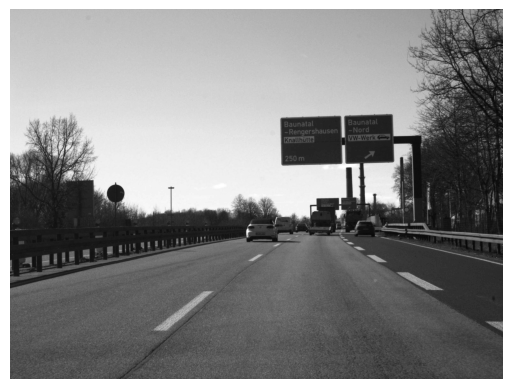

In [35]:

img_streetlines = cv2.imread('real_test.jpg', cv2.COLOR_BGR2RGB)
img = cv2.cvtColor(img_streetlines, cv2.COLOR_BGR2GRAY)

plt.imshow(img, cmap='gray')
plt.axis('off')

(-0.5, 222.5, 223.5, -0.5)

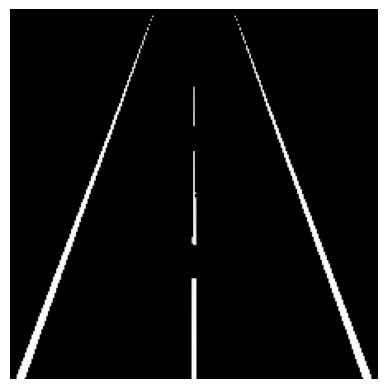

In [4]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Assuming img_streetlines is already defined as your input image
# Convert the RGB image (img_streetlines) to HSV color space
# OpenCV's H channel is 0-179
hsv_img = cv2.cvtColor(img_streetlines, cv2.COLOR_RGB2HSV)

# Define HSV bounds for white.
# Hue: 0-179 (all hues)
# Saturation: 0-50 (low saturation, i.e., grayish/white)
# Value: 200-255 (high brightness/value)
lower_white = np.array([0, 0, 200])
upper_white = np.array([179, 50, 255])

# Create a mask for white regions using the HSV image
white_mask = cv2.inRange(hsv_img, lower_white, upper_white)

# Isolate the white regions from the original RGB color image (img_streetlines)
color_isolated = cv2.bitwise_and(img_streetlines, img_streetlines, mask=white_mask)

# Display the result.
# color_isolated is already in RGB format because img_streetlines was RGB.
plt.imshow(color_isolated)
plt.axis('off')
plt.show()

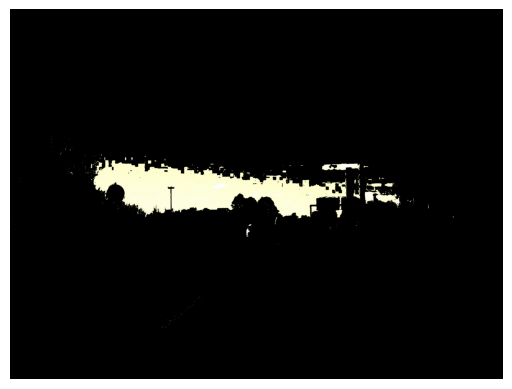

In [34]:
gray = cv2.cvtColor(color_isolated, cv2.COLOR_BGR2GRAY)

kernel_size = 5
blurred = cv2.GaussianBlur(gray, (kernel_size, kernel_size), 0)

plt.imshow(blurred, cmap='gray')
plt.axis('off')

(-0.5, 222.5, 223.5, -0.5)

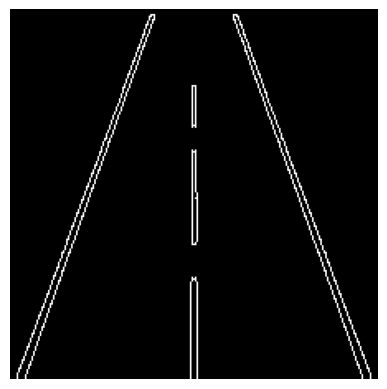

In [7]:
low_treshhold = 50
high_treshhold = 150
edges = cv2.Canny(blurred, low_treshhold, high_treshhold)
plt.imshow(edges, cmap='gray')
plt.axis('off')

(-0.5, 222.5, 223.5, -0.5)

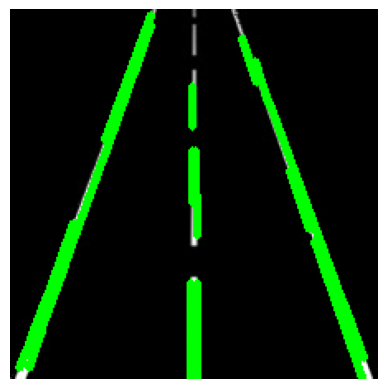

In [10]:
rho = 2
theta = np.pi / 180
threshold = 30
min_line_length = 20
max_line_gap = 1

lines = cv2.HoughLinesP(edges, rho, theta, threshold, np.array([]), minLineLength=min_line_length, maxLineGap=max_line_gap)

#plt.imshow(lines, cmap='gray')
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(img_streetlines, (x1, y1), (x2, y2), (0, 255, 0), 3)    

plt.imshow(img_streetlines)
plt.axis('off')


In [12]:
mxb =np.array([[0,0]])
for line in lines:
    for x1, y1, x2, y2 in line:
        if x1 == x2:  # Avoid division by zero for vertical lines
            continue
        m = (y2 - y1) / (x2 - x1)
        b = y1 - m * x1
        mxb = np.vstack((mxb, [m, b]))

median_right_m = np.median(mxb[mxb[:,0] > 0,0])
median_left_m = np.median(mxb[mxb[:,0] < 0,0])
median_right_b = np.median(mxb[mxb[:,0] > 0,1])
median_left_b = np.median(mxb[mxb[:,0] < 0,1])

# Calculate the Intersect point of our two lines
x_intersect = (median_left_b - median_right_b) / (median_right_m - median_left_m)
y_intersect = median_right_m * (median_left_b - median_right_b) / (median_right_m - median_left_m) + median_right_b
# Calculate the X-Intercept Points
    # x = (y - b) / m
left_bottom = (img_streetlines[0] - median_left_b) / median_left_m
right_bottom = (img_streetlines[0] - median_right_b) / median_right_m